In [1]:
from pathlib import Path
from pynwb import NWBHDF5IO

# getattr(对象, "属性名", 默认值) 用于安全地读取对象属性。
# 如果属性不存在，就返回默认值，而不是直接抛出 AttributeError。
# 例如 getattr(nwbfile, "subject", None) 表示：读取 subject，不存在则返回 None。

# 定位项目根目录；支持从仓库根或 single-session-baseline/ 目录执行。
WORKING_DIR = Path.cwd().resolve()
candidate_dirs = [WORKING_DIR, WORKING_DIR.parent, WORKING_DIR / "Reanalysis_DANDI469_NWB"]
DATA_DIR = next((path for path in candidate_dirs if (path / "raw").is_dir() and (path / "src").is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError(f"未找到项目根目录，当前工作目录: {WORKING_DIR}")

# 单 session 基线固定使用完整集中的 canonical sub-20_ses-2 文件。
baseline_file = DATA_DIR / "raw" / "all" / "000469" / "sub-20" / "sub-20_ses-2_ecephys+image.nwb"
if not baseline_file.is_file():
    baseline_file = DATA_DIR / "raw" / "pilot-legacy" / "sub-20_ses-2_ecephys+image.nwb"
if not baseline_file.is_file():
    raise FileNotFoundError(f"未找到单 session 基线 NWB 文件: {baseline_file}")

nwb_files = [baseline_file]
OUTPUT_DIR = DATA_DIR / "single-session-baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"数据目录: {DATA_DIR.resolve()}")
print(f"单 session 基线文件: {baseline_file.name}")

for file_path in nwb_files:
    print(f"\n{'=' * 70}")
    print(f"文件: {file_path.name}")

    try:
        # 只读打开文件，不修改原始 NWB 数据。
        with NWBHDF5IO(str(file_path), mode="r", load_namespaces=True) as io:
            nwbfile = io.read()

            # 这些元数据用于确认受试者和 session 是否正确。
            # subject 和 subject_id 可能是可选字段，因此使用 getattr 安全读取。
            subject = getattr(nwbfile, "subject", None)
            subject_id = getattr(subject, "subject_id", None)
            print("PyNWB 打开: PASS")

            # identifier 是 NWBFile 内部的文件或 session 标识符。
            # 它不是 DANDI 数据集编号，也不是受试者编号 subject_id。
            print(f"identifier: {nwbfile.identifier}")

            # session_start_time 是本次实验 session 在现实世界中的开始日期和时间。
            # trial 事件和 spike 时间通常用相对于 session 开始的秒数表示，
            # 但仍需结合实际字段确认时间基准，不能仅凭字段名假设。
            # 后续事件对齐的基本形式是：relative_time = spike_time - event_onset。
            print(f"session_start_time: {nwbfile.session_start_time}")
            print(f"subject_id: {subject_id}")

            # acquisition 和 processing 只列出名称，不加载其中的连续信号。
            print(f"acquisition: {list(nwbfile.acquisition.keys())}")
            print(f"processing: {list(nwbfile.processing.keys())}")

            # 项目最重要的三个 NWB 表：试次、神经元和电极。
            # getattr(nwbfile, "trials", None) 的含义是：
            # 尝试读取 trials；如果文件没有这个可选表，则保存为 None。
            tables = {
                "trials": getattr(nwbfile, "trials", None),
                "units": getattr(nwbfile, "units", None),
                "electrodes": getattr(nwbfile, "electrodes", None),
            }
            table_columns = {}

            for table_name, table in tables.items():
                if table is None:
                    print(f"{table_name}: MISSING")
                    table_columns[table_name] = []
                    continue

                # 只读取行数和列名，暂不读取 spike 数组等大字段。
                try:
                    row_count = len(table)
                except Exception:
                    row_count = "unknown"
                columns = list(table.colnames)
                table_columns[table_name] = columns
                print(f"{table_name}: rows={row_count}")
                print(f"{table_name} columns: {columns}")

            # 这些列名用于定位项目后续分析需要的事件和神经元字段。
            # 它们只是候选提示，字段的实际含义仍需结合数据说明确认。
            trial_keywords = ("encoding", "image", "fixation", "onset", "probe")
            event_candidates = [
                column
                for column in table_columns["trials"]
                if any(keyword in column.lower() for keyword in trial_keywords)
            ]
            print(f"trial event candidates: {event_candidates}")

            unit_keywords = ("spike", "electrode", "region", "location", "quality")
            unit_candidates = [
                column
                for column in table_columns["units"]
                if any(keyword in column.lower() for keyword in unit_keywords)
            ]
            print(f"unit spike/region candidates: {unit_candidates}")

            # 第一阶段必须至少存在三个核心表和 units.spike_times。
            core_tables_ok = all(table is not None for table in tables.values())
            spike_times_ok = "spike_times" in table_columns["units"]
            print(f"核心表 trials/units/electrodes: {'PASS' if core_tables_ok else 'REVIEW'}")
            print(f"units.spike_times: {'PASS' if spike_times_ok else 'REVIEW'}")
            print("注意：事件字段名称和时间基准需要在下一步数据字典中确认。")

    except Exception as exc:
        # 文件无法读取时给出明确错误，而不是继续进行后续分析。
        print("PyNWB 打开: FAIL")
        print(f"{type(exc).__name__}: {exc}")

数据目录: E:\BCI-workstation\NWB\Reanalysis_DANDI469_NWB
发现 1 个 NWB 文件

文件: sub-20_ses-2_ecephys+image.nwb
PyNWB 打开: PASS
identifier: SBID_20_P49CS
session_start_time: 2017-01-01 00:00:00-08:00
subject_id: 20
acquisition: ['events']
processing: []
trials: rows=135
trials columns: ['loads', 'loadsEnc1_PicIDs', 'loadsEnc2_PicIDs', 'loadsEnc3_PicIDs', 'loadsProbe_PicIDs', 'start_time', 'stop_time', 'timestamps_FixationCross', 'timestamps_Encoding1', 'timestamps_Encoding1_end', 'timestamps_Encoding2', 'timestamps_Encoding2_end', 'timestamps_Encoding3', 'timestamps_Encoding3_end', 'timestamps_Maintenance', 'timestamps_Probe', 'timestamps_Response', 'response_accuracy', 'probe_in_out']
units: rows=5
units columns: ['spike_times', 'electrodes', 'clusterID_orig', 'waveforms_mean_snr', 'waveforms_peak_snr', 'waveforms_isolation_distance', 'waveforms_mean_proj_dist']
electrodes: rows=5
electrodes columns: ['x', 'y', 'z', 'location', 'filtering', 'group', 'group_name', 'origChannel']
trial event cand

# 第一段：NWB 文件结构检查

## 从顶层设计看，这一段有什么用？

这一段对应顶层设计中的**只读检查文件**和**生成第一份结构报告**。在提取数据、计算放电率或绘图之前，必须先确认：目标 NWB 文件确实存在、PyNWB 能打开它，以及项目所需的 `trials`、`units`、`electrodes` 三张核心表和候选字段位于何处。

它只读取和打印结构信息，不会修改 NWB 文件，也不会把完整 spike 数组或 trial 表复制到新文件。它的作用是避免后续代码因为字段名、表位置或文件版本不符而在更晚阶段悄悄出错。

## 本次输出

- 数据目录：`Reanalysis_DANDI469_NWB`；发现 1 个 NWB 文件：`sub-20_ses-2_ecephys+image.nwb`。
- 文件打开：`PyNWB 打开: PASS`。
- session 信息：`identifier = SBID_20_P49CS`，`subject_id = 20`，`session_start_time = 2017-01-01 00:00:00-08:00`。
- 顶层模块：`acquisition = ['events']`，`processing = []`。
- `trials`：135 行；包含 `start_time`、`stop_time`、`timestamps_FixationCross`、`timestamps_Encoding1`、`timestamps_Encoding1_end`、probe 和行为相关字段。
- `units`：5 行；包含 `spike_times`、`electrodes` 和 SNR、isolation distance 等质量相关字段。
- `electrodes`：5 行；包含 `location`、空间坐标、`group` 和原始通道等字段。
- 核心结构结果：`trials/units/electrodes: PASS`，`units.spike_times: PASS`。

## 当前结论与边界

当前可以确认：本项目主分析所需的 trial 事件、unit spike 时间和电极/脑区入口都存在，能够进入数据字典阶段。此时只能把 `timestamps_Encoding1` 视为第一张编码图片 onset 的候选字段；事件语义、时间单位以及 spike 与事件是否处于同一时钟，仍需由下一段数据字典和后续时间完整性检查确认。

In [2]:
import json
import numpy as np
from pynwb import NWBHDF5IO

# 数据字典只记录字段映射和检查摘要，不转换原始 NWB 数据。
# 本单元依赖第一个单元已经生成的 nwb_files 和 DATA_DIR。

# 项目内部名称 -> 实际 NWB 表和字段 -> 字段含义。
FIELD_MAP = {
    "trial_start": ("trials", "start_time", "trial 开始时间"),
    "trial_stop": ("trials", "stop_time", "trial 结束时间"),
    "fixation_event": ("trials", "timestamps_FixationCross", "fixation 注视事件时间"),
    "first_encoding_onset": ("trials", "timestamps_Encoding1", "第一张编码图片开始时间"),
    "first_encoding_end": ("trials", "timestamps_Encoding1_end", "第一张编码图片结束时间"),
    "spike_times": ("units", "spike_times", "每个 unit 的 spike 时间数组"),
    "unit_electrode": ("units", "electrodes", "unit 到 electrodes 表的关联"),
    "region": ("electrodes", "location", "电极所在的解剖脑区或位置"),
}

def short(value, limit=140):
    # 长数组或 DataFrame 只保留简短示例，避免输出过长。
    text = repr(value).replace("\n", " ")
    return text if len(text) <= limit else text[:limit] + "..."

def missing(value):
    # 只把 None、空数组或全为 NaN 的数值标记为空。
    if value is None:
        return True
    try:
        array = np.asarray(value)
        return bool(array.size == 0 or (array.dtype.kind in "fc" and np.isnan(array).all()))
    except (TypeError, ValueError):
        return False

def json_default(value):
    # JSON 不支持 np.int64 等 NumPy 标量，转换成对应 Python 标量。
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"{type(value).__name__} is not JSON serializable")

def summarize(table, table_name, column_name, meaning):
    # 字段不存在时记录 MISSING，不让一个字段阻止整个报告生成。
    if table is None or column_name not in table.colnames:
        return {"status": "MISSING", "table": table_name, "column": column_name, "meaning": meaning}

    values = [table[column_name][i] for i in range(len(table))]
    numeric = []
    for value in values:
        try:
            array = np.asarray(value, dtype=float).ravel()
            numeric.extend(array[np.isfinite(array)].tolist())
        except (TypeError, ValueError):
            pass

    result = {
        "status": "FOUND",
        "table": table_name,
        "column": column_name,
        "meaning": meaning,
        "rows": len(values),
        "types": sorted({type(value).__name__ for value in values}),
        "missing": int(sum(missing(value) for value in values)),
        "examples": [short(value) for value in values[:3]],
    }
    if numeric:
        result["numeric_range"] = [min(numeric), max(numeric)]
    return result

# 重新打开文件，确保本单元不依赖第一个单元关闭前的文件对象。
file_path = nwb_files[0]
with NWBHDF5IO(str(file_path), mode="r", load_namespaces=True) as io:
    nwbfile = io.read()
    tables = {
        "trials": nwbfile.trials,
        "units": nwbfile.units,
        "electrodes": nwbfile.electrodes,
    }

    field_reports = []
    for analysis_name, (table_name, column_name, meaning) in FIELD_MAP.items():
        field_reports.append(
            summarize(tables[table_name], table_name, column_name, meaning)
        )
        field_reports[-1]["analysis_name"] = analysis_name

    # units.electrodes 是到 electrodes 表的关联；这里显示每个 unit 对应的 location。
    unit_locations = []
    for unit_index in range(len(nwbfile.units)):
        referenced_electrodes = nwbfile.units["electrodes"][unit_index]
        if hasattr(referenced_electrodes, "columns") and "location" in referenced_electrodes.columns:
            location = [str(value) for value in referenced_electrodes["location"].tolist()]
        else:
            location = short(referenced_electrodes)
        unit_locations.append({"unit_row": unit_index, "location": location})

dictionary_report = {
    "source_file": file_path.name,
    "nwb_identifier": nwbfile.identifier,
    "session_start_time": str(nwbfile.session_start_time),
    "fields": field_reports,
    "unit_to_electrode_location": unit_locations,
}

# 保存字段说明和检查摘要，不保存原始 trial 表或 spike 数组。
report_path = OUTPUT_DIR / "data_dictionary.json"
report_path.write_text(json.dumps(dictionary_report, ensure_ascii=False, indent=2, default=json_default), encoding="utf-8")

print(f"数据字典报告已保存: {report_path.resolve()}")
for report in field_reports:
    print(f"{report['analysis_name']} <- {report['table']}.{report['column']}: {report['status']}")
    if report["status"] == "FOUND":
        print(f"  type={report['types']}, missing={report['missing']}/{report['rows']}")
        print(f"  examples={report['examples']}")
        if "numeric_range" in report:
            print(f"  numeric_range={report['numeric_range']}")
print(f"unit -> electrode location: {unit_locations}")

数据字典报告已保存: E:\BCI-workstation\NWB\Reanalysis_DANDI469_NWB\data_dictionary.json
trial_start <- trials.start_time: FOUND
  type=['float64'], missing=0/135
  examples=['np.float64(19.34028875)', 'np.float64(27.150785749999997)', 'np.float64(35.55065775)']
  numeric_range=[19.34028875, 1179.14938575]
trial_stop <- trials.stop_time: FOUND
  type=['float64'], missing=0/135
  examples=['np.float64(27.12431675)', 'np.float64(35.53043875)', 'np.float64(44.03368575)']
  numeric_range=[27.12431675, 1187.45294475]
fixation_event <- trials.timestamps_FixationCross: FOUND
  type=['float64'], missing=0/135
  examples=['np.float64(19.34028875)', 'np.float64(27.150785749999997)', 'np.float64(35.55065775)']
  numeric_range=[19.34028875, 1179.14938575]
first_encoding_onset <- trials.timestamps_Encoding1: FOUND
  type=['float64'], missing=0/135
  examples=['np.float64(20.38491375)', 'np.float64(28.38422275)', 'np.float64(36.61737575)']
  numeric_range=[20.38491375, 1180.21607275]
first_encoding_end <- tri

# 第二段：数据字典与字段映射

## 从顶层设计看，这一段有什么用？

这一段对应顶层设计中的**建立数据字典**和**生成结构报告**。第一段只知道核心表和候选字段存在；这一段把项目内部使用的简短名称，例如 `first_encoding_onset`、`spike_times`、`region`，明确映射到本文件的实际 NWB 表和列名。后续分析只需遵循这些项目名称，就能追溯到原始字段的位置。

`FIELD_MAP` 是 Python 中的名称映射规则，本身只保存字符串和字段说明，并不复制 NWB 原始数据。代码根据它读取字段，汇总类型、缺失数、示例和数值范围，随后把摘要写入 `data_dictionary.json`。这个 JSON 是可阅读、可复核的报告，不保存完整的 135 行 trial 表或全部 spike 数组。

## 本次确认的映射和输出

- `trial_start <- trials.start_time`：135 个 `float64`，缺失 0，范围 19.340–1179.149 s。
- `trial_stop <- trials.stop_time`：135 个 `float64`，缺失 0，范围 27.124–1187.453 s。
- `fixation_event <- trials.timestamps_FixationCross`：135 个 `float64`，缺失 0。
- `first_encoding_onset <- trials.timestamps_Encoding1`：135 个 `float64`，缺失 0，范围 20.385–1180.216 s。
- `first_encoding_end <- trials.timestamps_Encoding1_end`：135 个 `float64`，缺失 0，范围 21.401–1181.233 s。
- `spike_times <- units.spike_times`：5 个 `ndarray`，缺失 0，整体范围 0.000–1508.457 s。
- `unit_electrode <- units.electrodes`：5 个关联结果，PyNWB 已将其解析为对应电极行的 `DataFrame`。
- `region <- electrodes.location`：5 个字符串，缺失 0。

unit 到脑区的对应为：unit 0 是左侧背侧前扣带皮层；unit 1、2、3 是右侧 pre-SMA；unit 4 是右侧杏仁核。报告已保存为 `data_dictionary.json`。

### `fixation_event` 的含义

`fixation_event = trials.timestamps_FixationCross` 是注视十字出现的**时间点**，不是完整时间段。例如，若它是 19.34 s、`encoding_onset` 是 20.38 s，则 fixation 时间段大致是 `[19.34, 20.38)` s。当前文件没有单独的 `fixation_end` 字段，所以把第一张图片 onset 视为 fixation 结束。后续主分析实际使用的是这段 fixation 中图片出现前最后 0.8 s，即 `baseline = [encoding_onset - 0.8, encoding_onset)`。

## 当前结论与边界

现在可以用 `timestamps_Encoding1` 作为第一张编码图片 onset 的项目入口，用 `spike_times` 进行事件对齐，并将结果追溯到电极和脑区。事件与 spike 的数值范围相互覆盖，说明使用同一时间轴的假设是合理的；但本段仍未逐个 trial 验证事件顺序、基线/响应窗口是否完整，也未检查每个 unit 的 spike 是否递增。这些内容由后续 trial QC 和 unit QC 完成。

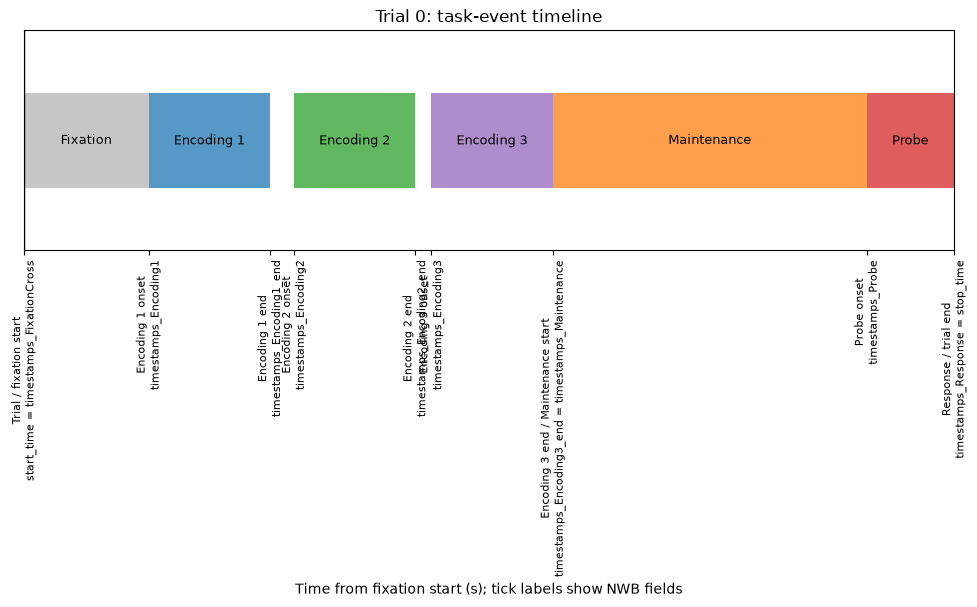

In [3]:
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO

# 使用第 0 个 trial 展示字段对应的任务时间顺序；0 s 定义为 fixation 十字出现。
EXAMPLE_TRIAL_ID = 0

with NWBHDF5IO(str(nwb_files[0]), mode="r", load_namespaces=True) as io:
    trial = io.read().trials.to_dataframe().loc[EXAMPLE_TRIAL_ID]

time_zero = trial["timestamps_FixationCross"]
phases = [
    ("Fixation", "timestamps_FixationCross", "timestamps_Encoding1", "0.7"),
    ("Encoding 1", "timestamps_Encoding1", "timestamps_Encoding1_end", "tab:blue"),
    ("Encoding 2", "timestamps_Encoding2", "timestamps_Encoding2_end", "tab:green"),
    ("Encoding 3", "timestamps_Encoding3", "timestamps_Encoding3_end", "tab:purple"),
    ("Maintenance", "timestamps_Maintenance", "timestamps_Probe", "tab:orange"),
    ("Probe", "timestamps_Probe", "timestamps_Response", "tab:red"),
]

fig, ax = plt.subplots(figsize=(12, 5.5))
for label, start_column, end_column, color in phases:
    # 绝对时间减去 fixation 开始时间，得到图中相对 0 s 的位置和持续时间。
    start = trial[start_column] - time_zero
    duration = trial[end_column] - trial[start_column]
    ax.broken_barh([(start, duration)], (4, 6), facecolors=color, alpha=0.75)
    ax.text(start + duration / 2, 7, label, ha="center", va="center", fontsize=9)

# 把每个关键时间点直接标为“任务含义 + 实际 NWB 变量名”，避免只看阶段条无法追溯字段。
event_ticks = [
    ("Trial / fixation start\nstart_time = timestamps_FixationCross", "timestamps_FixationCross"),
    ("Encoding 1 onset\ntimestamps_Encoding1", "timestamps_Encoding1"),
    ("Encoding 1 end\ntimestamps_Encoding1_end", "timestamps_Encoding1_end"),
    ("Encoding 2 onset\ntimestamps_Encoding2", "timestamps_Encoding2"),
    ("Encoding 2 end\ntimestamps_Encoding2_end", "timestamps_Encoding2_end"),
    ("Encoding 3 onset\ntimestamps_Encoding3", "timestamps_Encoding3"),
    ("Encoding 3 end / Maintenance start\ntimestamps_Encoding3_end = timestamps_Maintenance", "timestamps_Encoding3_end"),
    ("Probe onset\ntimestamps_Probe", "timestamps_Probe"),
    ("Response / trial end\ntimestamps_Response = stop_time", "timestamps_Response"),
]
tick_positions = [trial[column] - time_zero for _, column in event_ticks]
tick_labels = [label for label, _ in event_ticks]

# 黑线是 fixation 开始；其余关键时间点由下方竖排字段标签定位。
ax.axvline(0, color="black", linewidth=1)
ax.set_xlim(0, trial["stop_time"] - time_zero)
ax.set_ylim(0, 14)
ax.set_yticks([])
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)
ax.set_xlabel("Time from fixation start (s); tick labels show NWB fields")
ax.set_title(f"Trial {EXAMPLE_TRIAL_ID}: task-event timeline")
fig.subplots_adjust(bottom=0.48)
plt.show()

# 补充：单个 trial 的事件时间线

## 从顶层设计看，这一段有什么用？

这张图把数据字典中的多个绝对时间戳变成一个直观的任务流程。顶层设计要求先确认 fixation、三张编码图片、maintenance、probe 和 response 的顺序，才能合理定义图片 onset、基线窗和响应窗。

## 如何阅读图形

横轴的 0 s 是 `timestamps_FixationCross`，也就是注视十字出现。每个彩色条的左边界是该阶段开始时间，右边界是该阶段结束时间；条的长度是持续时间。图下方的竖排标签直接写出每个关键时间点对应的 NWB 变量名，并标明 `start_time = timestamps_FixationCross`、`timestamps_Encoding3_end = timestamps_Maintenance` 和 `timestamps_Response = stop_time`。第 0 个 trial 中，fixation 为 0–1.045 s，第一张编码图片为 1.045–2.061 s，第二张为 2.261–3.277 s，第三张为 3.411–4.427 s，maintenance 为 4.427–7.056 s，随后是 probe，7.784 s 时 response/trial 结束。

## 当前结论与边界

这张图说明实际字段如何组成一个 Sternberg trial，也解释了为什么 `timestamps_Encoding1` 可作为第一张图片 onset、为什么 fixation 可提供图片前的基线。它只展示第 0 个 trial，不能证明全部 135 个 trial 都满足同样的时间关系；下一段 trial QC 会逐条检查全部 trial 的事件顺序和窗口覆盖。

In [4]:
import numpy as np
from pynwb import NWBHDF5IO

# 主分析预先定义的时间窗口：编码前 0.8 s 的 fixation 基线，
# 以及编码后 [0.2, 1.0) s 的响应窗口。
BASELINE_SECONDS = 0.8
RESPONSE_END_SECONDS = 1.0

# 本单元依赖第一个单元生成的 nwb_files。
COLUMNS = [
    "start_time", "stop_time", "timestamps_FixationCross",
    "timestamps_Encoding1", "timestamps_Encoding1_end",
]

with NWBHDF5IO(str(nwb_files[0]), mode="r", load_namespaces=True) as io:
    nwbfile = io.read()
    trial_qc = nwbfile.trials.to_dataframe()[COLUMNS]

# 使用简短列名建立后续分析用的 trial 表；原始 NWB 文件不被修改。
trial_qc = trial_qc.rename(columns={
    "start_time": "trial_start",
    "stop_time": "trial_stop",
    "timestamps_FixationCross": "fixation",
    "timestamps_Encoding1": "encoding_onset",
    "timestamps_Encoding1_end": "encoding_end",
})

TIME_COLUMNS = ["trial_start", "trial_stop", "fixation", "encoding_onset", "encoding_end"]
# 四项核心检查：时间有效、事件顺序正确、基线完整、响应窗口完整。
trial_qc["finite_times"] = np.isfinite(trial_qc[TIME_COLUMNS]).all(axis=1)
trial_qc["event_order"] = (trial_qc["trial_start"] <= trial_qc["fixation"]) & (trial_qc["fixation"] < trial_qc["encoding_onset"]) & (trial_qc["encoding_onset"] < trial_qc["encoding_end"]) & (trial_qc["encoding_end"] <= trial_qc["trial_stop"])
trial_qc["baseline_covered"] = trial_qc["encoding_onset"] - BASELINE_SECONDS >= trial_qc["fixation"]
trial_qc["response_covered"] = trial_qc["encoding_onset"] + RESPONSE_END_SECONDS <= trial_qc["trial_stop"]

CHECK_COLUMNS = ["finite_times", "event_order", "baseline_covered", "response_covered"]
trial_qc["keep"] = trial_qc[CHECK_COLUMNS].all(axis=1)
valid_trials = trial_qc.loc[trial_qc["keep"]].copy()

print(f"总 trial 数: {len(trial_qc)}")
print("各项排除数:")
print((~trial_qc[CHECK_COLUMNS]).sum())
print(f"保留用于后续对齐的 trial: {len(valid_trials)}")

# 若有排除项，显示其时间和未通过的规则；没有则显示空表。
trial_qc.loc[~trial_qc["keep"], TIME_COLUMNS + CHECK_COLUMNS].head(10)

总 trial 数: 135
各项排除数:
finite_times        0
event_order         0
baseline_covered    0
response_covered    0
dtype: int64
保留用于后续对齐的 trial: 135


,trial_start,trial_stop,fixation,encoding_onset,encoding_end,finite_times,event_order,baseline_covered,response_covered
id,,,,,,,,,


# 第三段：trial 时间完整性检查（trial QC）

## 从顶层设计看，这一段有什么用？

这一段对应顶层设计中的 **Trial 纳入** 和质量控制。主问题要比较同一 trial 内的 fixation 基线与第一张图片后的放电率，因此不能只知道 onset 字段存在，还必须确认每个 trial 的事件顺序正确，而且预先定义的基线窗 `[-0.8, 0)` 和响应窗 `[0.2, 1.0)` 都没有超出可用 trial 时间。

代码将原始时间字段改成简短列名，形成内存中的 `trial_qc` 表；它不修改 NWB 文件。通过全部规则的行保存为 `valid_trials`，供后续每个 unit 的 spike 对齐使用。

## 检查规则

- `finite_times`：`trial_start`、`trial_stop`、`fixation`、`encoding_onset` 和 `encoding_end` 都必须是有限数值，不能为 NaN 或无穷大。
- `event_order`：事件必须满足 `trial_start <= fixation < encoding_onset < encoding_end <= trial_stop`。当前文件中 `trial_start = fixation` 是允许的。
- `baseline_covered`：`encoding_onset - 0.8 >= fixation`，表示图片前至少有 0.8 s fixation 可作为基线。
- `response_covered`：`encoding_onset + 1.0 <= trial_stop`，表示图片后至少有 1.0 s 可用于响应窗。
- `keep`：以上四项全为真时，该 trial 才被纳入 `valid_trials`。

## 本次输出

- 总 trial 数：135。
- `finite_times`、`event_order`、`baseline_covered`、`response_covered` 的排除数均为 0。
- `valid_trials`：135 行，即全部 trial 被保留。
- 输出末尾的 `Empty DataFrame` 是被排除 trial 的列表；它为空表示没有 trial 违反这些规则，不表示原始数据为空。

## 当前结论与边界

这 135 个 trial 都具有完整、顺序合理的 fixation 与第一张图片事件，可公平比较同一 trial 内的基线和图片后窗口。此结论只解决 trial 时间结构；每个 unit 的 spike 是否有效、递增且足够活跃，仍需下一段 unit QC 检查。

In [5]:
import numpy as np
from pynwb import NWBHDF5IO

# 最低活动规则：unit 至少在 10 个保留 trial 中出现 spike。
MIN_ACTIVE_TRIALS = 10

with NWBHDF5IO(str(nwb_files[0]), mode="r", load_namespaces=True) as io:
    nwbfile = io.read()
    unit_qc = nwbfile.units.to_dataframe()[[
        "spike_times", "waveforms_mean_snr", "waveforms_peak_snr",
        "waveforms_isolation_distance",
    ]].copy()

# valid_trials 来自第三个单元；用完整 trial 区间统计每个 unit 的活动 trial 数。
starts = valid_trials["trial_start"].to_numpy()
stops = valid_trials["trial_stop"].to_numpy()
spikes = [np.asarray(value) for value in unit_qc["spike_times"]]
unit_qc["spike_count"] = [len(value) for value in spikes]
unit_qc["finite_spikes"] = [np.isfinite(value).all() for value in spikes]
unit_qc["increasing_spikes"] = [
    finite and np.all(np.diff(value) >= 0)
    for value, finite in zip(spikes, unit_qc["finite_spikes"])
]
unit_qc["active_trials"] = [
    int((np.searchsorted(value, stops) > np.searchsorted(value, starts)).sum())
    if increasing else 0
    for value, increasing in zip(spikes, unit_qc["increasing_spikes"])
]
unit_qc["enough_activity"] = unit_qc["active_trials"] >= MIN_ACTIVE_TRIALS
unit_qc["keep"] = unit_qc[["finite_spikes", "increasing_spikes", "enough_activity"]].all(axis=1)
valid_units = unit_qc.loc[unit_qc["keep"]].copy()

# SNR 和 isolation distance 仅报告；isolation_distance 缺失时不把 unit 自动排除。
print(unit_qc.drop(columns="spike_times"))
print(f"保留用于后续对齐的 unit: {len(valid_units)}/{len(unit_qc)}")

    waveforms_mean_snr  waveforms_peak_snr  waveforms_isolation_distance  \
id                                                                         
0             0.842963            3.738961                           NaN   
1             0.662956            4.133045                           NaN   
2             0.709953            4.412684                           NaN   
3             0.887514            3.965296                           NaN   
4             1.322818            5.959232                     18.150095   

    spike_count  finite_spikes  increasing_spikes  active_trials  \
id                                                                 
0          2255           True               True            133   
1          2318           True               True            128   
2          2647           True               True            131   
3          2585           True               True            134   
4          1454           True               True          

# 第四段：unit 最低质量控制（unit QC）

## 从顶层设计看，这一段有什么用？

这一段对应顶层设计中的 **Unit 纳入**。trial QC 保证时间窗可用；unit QC 则保证进入 spike 对齐和放电率计算的神经元具有可用的 spike 时间序列和足够的任务期活动。它筛选的是记录与数据结构质量，不根据图片后是否有更高放电来挑选 unit。

代码读取通过 trial QC 的 `valid_trials`，然后为每个 unit 建立 `unit_qc` 表。通过全部最低规则的 unit 保存为 `valid_units`，供后续 `unit × trial` 特征计算使用。

## 检查规则

- `spike_count`：该 unit 在整个 session 中的 spike 总数。
- `finite_spikes`：所有 spike 时间必须是有限数值，不能为 NaN 或无穷大。
- `increasing_spikes`：spike 时间必须单调递增；这是用 `searchsorted` 正确按时间窗计数的前提。
- `active_trials`：在每个保留 trial 的完整时间范围内，只要至少出现 1 个 spike，就计为 1 个活动 trial。
- `enough_activity`：活动 trial 数必须至少为 10，这是当前项目冻结的最低活动规则。
- `keep`：`finite_spikes`、`increasing_spikes` 和 `enough_activity` 必须全部为真。

## 本次输出

- unit 0–4 的 spike 总数分别为 2255、2318、2647、2585、1454。
- 5 个 unit 的 `finite_spikes` 和 `increasing_spikes` 均为 `True`。
- 活动 trial 数分别为 133、128、131、134、89，均高于最低阈值 10。
- 5 个 unit 的 `enough_activity` 与 `keep` 均为 `True`，因此 `valid_units` 为 5/5。
- 输出同时报告波形 SNR 和 isolation distance：5 个 unit 都有 mean/peak SNR；只有 unit 4 有 `waveforms_isolation_distance = 18.150095`，其余 4 个为缺失值。

## 当前结论与边界

当前 5 个 unit 都满足项目的最低 spike 完整性与活动量要求，可以进入事件对齐和窗口放电率计算。缺失的 isolation distance 不应被解释成自动不合格，因此当前仅报告它而不设临时阈值。该最低 QC 尚未检查 ISI violation、重复 unit、异常高放电 trial 或更完整的波形质量；这些应在后续结果核查中继续报告。unit 到电极和脑区的关联已在数据字典阶段确认。

In [6]:
import numpy as np
import pandas as pd

# 相对第一张编码图片 onset 的两个左闭右开时间窗，单位为秒。
BASELINE_WINDOW = (-0.8, 0.0)
RESPONSE_WINDOW = (0.2, 1.0)
WINDOW_SECONDS = 0.8

records = []
for unit_id, unit in valid_units.iterrows():
    spike_times = np.asarray(unit["spike_times"])  # 第四个单元已确认其递增。
    for trial_id, onset in valid_trials["encoding_onset"].items():
        # searchsorted(left) 计算 [left, right) 内的 spike 数，不需要复制相对时间数组。
        baseline_count = np.searchsorted(spike_times, onset + BASELINE_WINDOW[1]) - np.searchsorted(spike_times, onset + BASELINE_WINDOW[0])
        response_count = np.searchsorted(spike_times, onset + RESPONSE_WINDOW[1]) - np.searchsorted(spike_times, onset + RESPONSE_WINDOW[0])
        records.append({
            "unit_id": unit_id,
            "trial_id": trial_id,
            "baseline_count": baseline_count,
            "response_count": response_count,
        })

unit_trial_features = pd.DataFrame(records)
unit_trial_features["baseline_rate_hz"] = unit_trial_features["baseline_count"] / WINDOW_SECONDS
unit_trial_features["response_rate_hz"] = unit_trial_features["response_count"] / WINDOW_SECONDS
unit_trial_features["rate_difference_hz"] = unit_trial_features["response_rate_hz"] - unit_trial_features["baseline_rate_hz"]

print(f"unit x trial 特征行数: {len(unit_trial_features)}")
unit_trial_features.groupby("unit_id")[["baseline_rate_hz", "response_rate_hz", "rate_difference_hz"]].mean().round(3)

unit x trial 特征行数: 675


,baseline_rate_hz,response_rate_hz,rate_difference_hz
unit_id,,,
0,2.028,2.241,0.213
1,2.019,2.259,0.241
2,2.694,2.722,0.028
3,2.389,2.130,-0.259
4,1.046,1.148,0.102


# 第五段：按 unit × trial 计算窗口放电率

## 从顶层设计看，这一段有什么用？

这一段对应顶层设计中的**事件对齐**和**计算窗口特征**。对每个合格 unit 的每个合格 trial，以 `encoding_onset` 为 0 s，计算基线 `[-0.8, 0)` 与响应 `[0.2, 1.0)` 内的 spike 数和放电率。两个窗口都是 0.8 s，因此 spike 数除以 0.8 得到 Hz。

代码生成 `unit_trial_features`：每一行不是单独的 unit，也不是单独的 trial，而是一个明确的 `unit × trial` 配对观察。它保留 `baseline_count`、`response_count`、两种放电率和 `rate_difference_hz = response_rate_hz - baseline_rate_hz`，供后续可视化和 unit 内统计检验使用。

## 本次输出

- 特征表共有 675 行，即 5 个 `valid_units` × 135 个 `valid_trials`。
- unit 0–4 的平均 baseline_rate_hz 分别为 2.028、2.019、2.694、2.389、1.046 Hz。
- unit 0–4 的平均 response_rate_hz 分别为 2.241、2.259、2.722、2.130、1.148 Hz。
- 平均 response-baseline 差分别为 0.213、0.241、0.028、-0.259、0.102 Hz。

## 当前结论与边界

这些数值是每个 unit 跨 135 个配对 trial 的描述性均值。它们说明 unit 0、1、2、4 的平均响应略高于基线，而 unit 3 略低；但不能据此宣布任何 unit 显著响应。675 行也不是 675 个独立样本，主要推断单位仍是 unit，trial 是 unit 内的重复观测。

unit_trial_matrix shape: (5, 135)


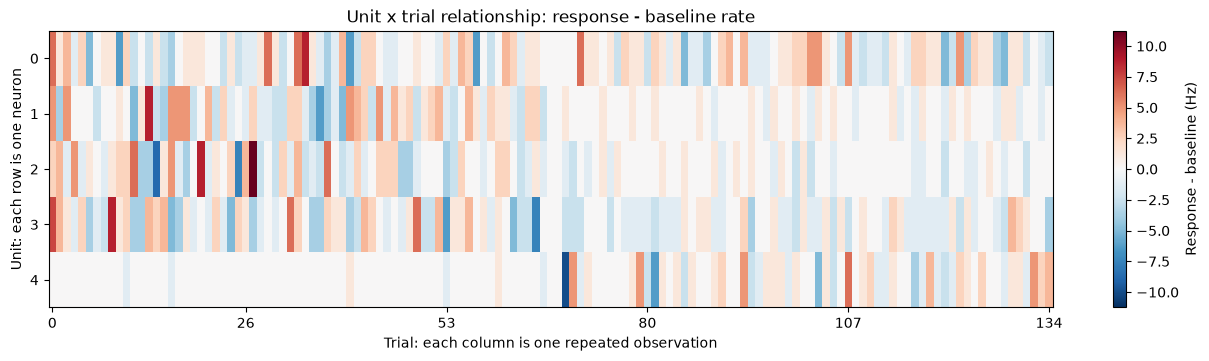

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 每个小格对应一个 unit × trial 的配对观察；颜色表示该 trial 的 response - baseline 放电率差。
unit_trial_matrix = unit_trial_features.pivot(
    index="unit_id", columns="trial_id", values="rate_difference_hz"
)

# 使用以 0 为中心的对称颜色范围：蓝色为图片后低于基线，红色为高于基线。
color_limit = max(np.abs(unit_trial_matrix.to_numpy()).max(), 0.1)
fig, ax = plt.subplots(figsize=(12, 3.5), constrained_layout=True)
image = ax.imshow(
    unit_trial_matrix, aspect="auto", cmap="RdBu_r",
    vmin=-color_limit, vmax=color_limit, interpolation="nearest",
)

tick_positions = np.linspace(0, len(unit_trial_matrix.columns) - 1, 6, dtype=int)
ax.set_xticks(tick_positions, unit_trial_matrix.columns[tick_positions])
ax.set_yticks(np.arange(len(unit_trial_matrix.index)), unit_trial_matrix.index)
ax.set_xlabel("Trial: each column is one repeated observation")
ax.set_ylabel("Unit: each row is one neuron")
ax.set_title("Unit x trial relationship: response - baseline rate")
fig.colorbar(image, ax=ax, label="Response - baseline (Hz)")
print(f"unit_trial_matrix shape: {unit_trial_matrix.shape}")
plt.show()

# 补充：unit 与 trial 的关系

## 如何阅读图形

图有 5 行、135 列。每一行是一位神经元（unit），每一列是一次任务试次（trial），每个小格就是该 unit 在该 trial 的一个配对观察：`response_rate_hz - baseline_rate_hz`。红色表示图片后放电率高于该 trial 内的基线，蓝色表示低于基线，接近白色表示差异接近 0。

这张图直观表达了分析层级：同一个 unit 在 135 个 trial 中被重复观察；同一个 trial 同时为 5 个 unit 提供一次观察。因而共有 `5 × 135 = 675` 个小格，但它们不能被当作 675 个独立受试者样本。后续统计应在每个 unit 内使用其 135 个配对差值，而不是把所有小格简单合并。

## 从顶层设计看，这一段有什么用？

它把顶层设计中“主要推断单位是 unit，trial 是 unit 内重复观测”的原则变成可见的数据结构检查。图中的颜色只是单 trial 的描述性差值，不代表显著性，也不应用于挑选结果最好的 unit。

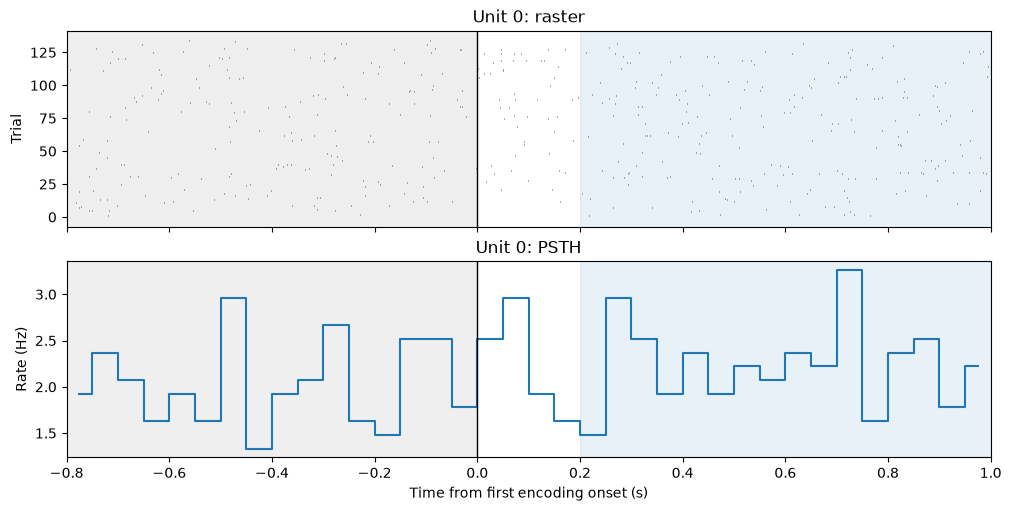

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 图的横轴相对第一张编码图片 onset，单位为秒。
PLOT_WINDOW = (-0.8, 1.0)
BIN_WIDTH = 0.05  # PSTH 每个 bin 为 50 ms。
BIN_EDGES = np.linspace(PLOT_WINDOW[0], PLOT_WINDOW[1], 37)

def plot_unit(unit_id, raster_ax, psth_ax):
    # 这个函数不返回新数据，而是把同一个 unit 的两张图直接画到传入的两个坐标轴上。
    # unit_id 指定要画哪个神经元；raster_ax 是 raster 的画布，psth_ax 是 PSTH 的画布。
    # valid_units 中的 spike_times 是相对于 session 开始的绝对时间，例如 20.5 s、20.8 s。
    spike_times = np.asarray(valid_units.loc[unit_id, "spike_times"])

    # 对 135 个 trial 逐一做相同的时间移动：把各自的图片 onset 都视为 0 s。
    # aligned_spikes 会保存 135 个数组；第 i 个数组就是第 i 个 trial 的相对 spike 时间。
    aligned_spikes = []
    for onset in valid_trials["encoding_onset"]:
        # 先在绝对时间轴上取 [onset-0.8, onset+1.0) 内的 spike。
        # 常用语法：np.searchsorted(a, v, side="left")。a 必须是递增数组，v 是要查找的数值，
        # 返回 v 应插入 a 的索引；side="left" 表示插在第一个 >= v 的元素之前，也是默认值。
        # searchsorted 返回该边界应插入递增 spike_times 的索引：left 对应第一个 >= 左边界的 spike，
        # right 对应第一个 >= 右边界的 spike，因此 spike_times[left:right] 正好是左闭右开的时间窗。
        left = np.searchsorted(spike_times, onset + PLOT_WINDOW[0])
        right = np.searchsorted(spike_times, onset + PLOT_WINDOW[1])
        # 减去本 trial 的 onset，将绝对时间改为相对时间：-0.3 表示图片前 0.3 s，
        # 0.4 表示图片后 0.4 s。即使一个 trial 没有 spike，也保留空数组以维持 trial 行号。
        aligned_spikes.append(spike_times[left:right] - onset)

    # Raster：eventplot 把 aligned_spikes 的每个数组画成一行，每个 spike 画成一根短黑线。
    # 因此横向位置是相对图片 onset 的时间，纵向位置只标识该 spike 属于第几个 trial。
    raster_ax.eventplot(aligned_spikes, colors="black", linewidths=0.45, linelengths=0.7)
    raster_ax.set_ylabel("Trial")
    raster_ax.set_title(f"Unit {unit_id}: raster")

    # PSTH：先把 135 个 trial 的相对 spike 数组合并，再按 BIN_EDGES 的 50 ms 小格计数。
    # counts[j] 是第 j 个时间 bin 内、所有 trial 合计出现的 spike 数。
    counts, _ = np.histogram(np.concatenate(aligned_spikes), bins=BIN_EDGES)
    # 除以 trial 数和 bin 宽度，将总 spike 数换成每个 trial 的平均放电率，单位 Hz。
    psth_hz = counts / (len(aligned_spikes) * BIN_WIDTH)
    # histogram 返回的是每个 bin 的左右边界；取中点后，阶梯线才会落在对应的时间位置。
    centers = (BIN_EDGES[:-1] + BIN_EDGES[1:]) / 2
    psth_ax.step(centers, psth_hz, where="mid", color="tab:blue")
    psth_ax.set_ylabel("Rate (Hz)")
    psth_ax.set_title(f"Unit {unit_id}: PSTH")

    # 以下标记只帮助阅读图形，不参与任何 spike 计数：灰色是基线窗 [-0.8, 0)，
    # 浅蓝色是响应窗 [0.2, 1.0)，黑色竖线 0 s 是第一张编码图片 onset。
    # 对 raster 和 PSTH 使用完全相同的横轴标记，便于将单 trial 模式与平均放电率对应起来。
    for ax in (raster_ax, psth_ax):
        ax.axvspan(-0.8, 0.0, color="0.7", alpha=0.2)
        ax.axvspan(0.2, 1.0, color="tab:blue", alpha=0.1)
        ax.axvline(0.0, color="black", linewidth=1)
        ax.set_xlim(PLOT_WINDOW)

EXAMPLE_UNIT_ID = valid_units.index[0]
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True, constrained_layout=True)
plot_unit(EXAMPLE_UNIT_ID, axes[0], axes[1])
axes[1].set_xlabel("Time from first encoding onset (s)")
plt.show()

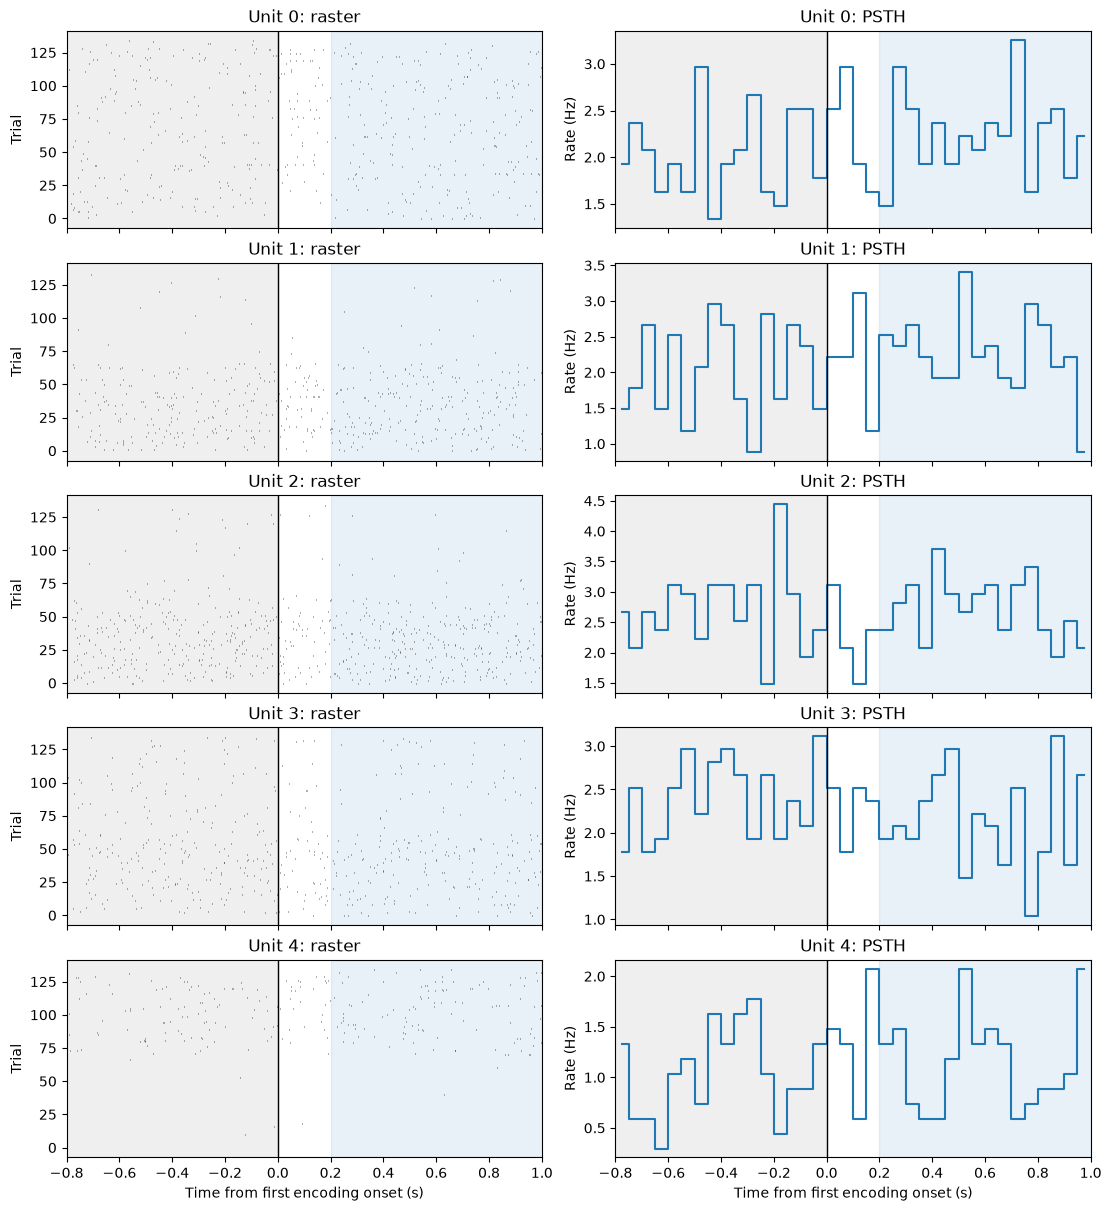

In [9]:
# 使用第六个单元定义的 plot_unit()，对全部合格 unit 重复相同的对齐与绘图。
unit_ids = valid_units.index.to_list()
fig, axes = plt.subplots(len(unit_ids), 2, figsize=(11, 2.4 * len(unit_ids)), sharex=True, constrained_layout=True)

for unit_id, (raster_ax, psth_ax) in zip(unit_ids, axes):
    plot_unit(unit_id, raster_ax, psth_ax)

axes[-1, 0].set_xlabel("Time from first encoding onset (s)")
axes[-1, 1].set_xlabel("Time from first encoding onset (s)")
plt.show()

# 第六、七段：事件对齐 raster 与 PSTH

## 这两个代码块如何配合？

第六段先定义 `plot_unit(unit_id, raster_ax, psth_ax)`：这是“如何对一个 unit 做对齐并绘图”的完整模板。它从 `valid_units` 取该 unit 的绝对 spike 时间，对 135 个 `valid_trials` 分别减去 `encoding_onset`，只保留相对时间 `[-0.8, 1.0)` s 内的 spike，然后在传入的两个坐标轴上画 raster 和 PSTH。第六段再调用一次该函数，画出 unit 0 的示例图。

第七段不重复对齐与绘图逻辑，只遍历全部 5 个 `valid_units` 并重复调用 `plot_unit()`。因此必须先运行第六段，才能让第七段使用已经定义的函数。

## 从顶层设计看，这一组图有什么用？

顶层设计要求在统计检验前先画少量 unit 的 raster 和 PSTH，检查 spike-event 对齐的时间方向、单位和合理性。它们不是主要统计检验，而是可视化质量控制：如果所有 spike 挤在 0 s、图完全空白或时间方向明显不合理，就应先回查事件字段和时间基准，而不是直接解释放电率差。

## 如何阅读图形

- **Raster（左/上图）**：135 行中的每一行是一个 trial；一根短黑线是一枚 spike；横向位置是相对第一张图片 onset 的时间。它显示单个 trial 的放电分布和是否存在跨 trial 一致的时间聚集。
- **PSTH（右/下图）**：将 135 个 trial 的相对 spike 合并，按 50 ms bin 计数，并除以 `135 × 0.05 s` 转换为 Hz。它显示该 unit 的平均放电率如何随图片 onset 前后时间变化。
- 两张图的黑色竖线是 0 s，即 `encoding_onset`；灰色区域是基线窗 `[-0.8, 0)`；浅蓝色区域是响应窗 `[0.2, 1.0)`。0–0.2 s 的白色区域是预先保留的早期视觉输入/显示延迟缓冲，不进入主要基线或响应比较。

## 运行后的输出

- 第六段输出 1 张图，含 unit 0 的 raster 和 PSTH 两个子图。
- 第七段输出 1 张总图，共 5 行 × 2 列：每行对应一个 unit，左列为 raster，右列为 PSTH。
- 当前 notebook 尚未保存这两段图的输出；运行相应单元即可重新生成图形。

## 当前结论与边界

这组图用于直观核对对齐和描述时间过程。PSTH 中局部较高或较低的 bin、raster 中局部较密或较稀的短线，都不能单独证明 unit 显著响应图片。显著性仍需基于每个 unit 的 135 个配对 `response_rate - baseline_rate` 差值进行后续 unit 内统计检验。

In [10]:
import numpy as np
import pandas as pd

# 2 ms 以下的 ISI 作为报告性筛查指标；本单元不据此临时排除 unit。
SHORT_ISI_SECONDS = 0.002
qc_rows = []

for unit_id, unit in valid_units.iterrows():
    spike_times = np.asarray(unit["spike_times"])
    isi = np.diff(spike_times)
    features = unit_trial_features.loc[unit_trial_features["unit_id"] == unit_id]
    qc_rows.append({
        "unit_id": unit_id,
        "min_isi_ms": isi.min() * 1000,
        "short_isi_count": (isi < SHORT_ISI_SECONDS).sum(),
        "short_isi_fraction": (isi < SHORT_ISI_SECONDS).mean(),
        "baseline_zero_fraction": (features["baseline_count"] == 0).mean(),
        "response_zero_fraction": (features["response_count"] == 0).mean(),
        "max_baseline_count": features["baseline_count"].max(),
        "max_response_count": features["response_count"].max(),
    })

final_qc = pd.DataFrame(qc_rows).set_index("unit_id")
print(final_qc.round(4))
print("统计前仍需人工确认：运行并检查第七个代码块的全部 unit raster/PSTH。")

         min_isi_ms  short_isi_count  short_isi_fraction  \
unit_id                                                    
0            1.9375                2              0.0009   
1            1.8750                1              0.0004   
2            1.9375                1              0.0004   
3            1.8750                1              0.0004   
4            2.0000                1              0.0007   

         baseline_zero_fraction  response_zero_fraction  max_baseline_count  \
unit_id                                                                       
0                        0.2074                  0.2148                   6   
1                        0.4370                  0.3778                   8   
2                        0.3407                  0.4000                   9   
3                        0.1852                  0.2815                   6   
4                        0.5630                  0.5630                   8   

         max_response_cou

# 最后一段统计前 QC：ISI、零计数与极端计数

## 从顶层设计看，这一段有什么用？

这一段补充顶层设计中 unit QC 尚未量化的项目：极短 ISI、基线/响应窗口零计数，以及单 trial 的最大 spike count。它不是新的神经响应分析，而是进入主要统计前的透明核查，帮助判断后续结果是否可能由异常 spike 序列、低计数或少数异常 trial 驱动。

## 三个术语的简单解释

- **ISI（相邻 spike 间隔）**：同一个 unit 连续两枚 spike 之间相隔的时间。大量极短间隔可能提示 spike sorting 不够干净、不同神经元混入同一个 unit，或重复检测。
- **零计数**：某个 trial 的 0.8 s 基线窗或响应窗中一枚 spike 都没有。它通常表示放电稀疏，不是缺失数据；零值很多时，应避免默认正态检验。
- **极端计数**：某一个 trial 的窗口 spike 数远高于该 unit 的其他 trial。少数异常高值可能抬高平均放电率，因此需要记录最大计数并结合图形判断。

## 本次输出

- unit 0–4 的最短 ISI 分别为 1.9375、1.8750、1.9375、1.8750、2.0000 ms。
- 小于 2 ms 的 ISI 比例分别约为 0.000887、0.000432、0.000378、0.000387、0.000688，均低于 0.1%。
- 基线零计数比例分别为 0.207、0.437、0.341、0.185、0.563；响应零计数比例分别为 0.215、0.378、0.400、0.281、0.563。低放电 unit 的零计数并不等同于数据错误，但说明后续应使用配对置换检验，而不依赖正态近似。
- 响应窗口中的最大单 trial spike count 为 7、8、11、8、5，没有出现需要在当前阶段自动剔除的明显极端值。

## 当前结论与边界

当前 5 个 unit 通过了已实现的 trial QC、最低 unit QC 和报告性 ISI/计数检查，具备进入主要统计的条件。极短 ISI 指标在此仅作透明报告，不使用未预先声明的数据集专用阈值临时排除 unit。进入统计前仍应在 notebook 中运行并人工检查第七个代码块的全部 unit raster/PSTH，确认没有明显的系统性时间错位。

In [11]:
import numpy as np
import pandas as pd

# 固定随机种子与置换次数（来自顶层设计第 20 节，查看结果前冻结）。
RNG = np.random.default_rng(20260901)
PERMUTATIONS = 10_000

# 对每个 unit，收集它在全部保留 trial 中的配对差值。
# unit_trial_features 每一行是一个 unit × trial 观察，
# d = rate_difference_hz = response_rate_hz - baseline_rate_hz（两窗等长，可直接配对）。
study_unit_ids = sorted(unit_trial_features["unit_id"].unique())
test_rows = []

for unit_id in study_unit_ids:
    d = unit_trial_features.loc[
        unit_trial_features["unit_id"] == unit_id, "rate_difference_hz"
    ].to_numpy()
    n_trials = d.size
    observed_mean = float(d.mean())

    # 配对置换检验：在同一 trial 内随机交换 baseline 与 response 标签。
    # 因为两个窗口等长，交换标签等价于把该 trial 的差值 d_i 随机取负号（±d_i）。
    # 这样每次置换都在 trial 内完成，保留“trial 是 unit 内重复观测”的配对结构。
    # 置换零分布 = 大量随机翻符号后的均值；观测均值位于该分布的相对位置给出单尾方向性 p。
    signs = RNG.choice([-1.0, 1.0], size=(PERMUTATIONS, n_trials))
    null_means = (signs * d).mean(axis=1)

    # 方向性 p（H1：平均差值高于 0）：零分布中达到或超过观测均值的比例。
    # +1/+1 为连续性校正，避免观测值恰好位于最极端时出现 0。
    p_value = float((null_means >= observed_mean).sum() + 1) / (PERMUTATIONS + 1)

    test_rows.append({
        "unit_id": unit_id,
        "n_trials": n_trials,
        "mean_delta_hz": observed_mean,
        "permutation_p": p_value,
    })

unit_perm_test = pd.DataFrame(test_rows).set_index("unit_id")
print(unit_perm_test.round(4))

         n_trials  mean_delta_hz  permutation_p
unit_id                                        
0             135         0.2130         0.1952
1             135         0.2407         0.1169
2             135         0.0278         0.4635
3             135        -0.2593         0.8924
4             135         0.1019         0.2930


# 第六段（里程碑 6）主检验第 1 步：每个 unit 是否真的在图片后更活跃？

## 这一段到底在问什么？

前面已经确认 135 个 trial 和 5 个 unit 都可以使用。现在不再只看一张平均图，而是对**每个 unit 的 135 个 trial**逐一比较：同一个 trial 中，图片后 0.2–1.0 s 的放电率，是否通常高于图片前 -0.8–0 s 的 fixation 基线放电率？

对每一个 trial，代码先算一个差值：

    该 trial 的差值 = 图片后放电率 - 图片前基线放电率

差值大于 0，表示该 trial 图片后更活跃；小于 0，表示图片后更低；等于 0，表示两个窗口一样。每个 unit 会得到 135 个这样的差值，`mean_delta_hz` 就是它们的平均数。

仅仅看到平均数大于 0 还不够。例如 Unit 1 的平均差值是 +0.241 Hz，但这可能是图片的真实影响，也可能只是 135 个 trial 自然起伏后碰巧得到的正数。本步用**配对置换检验**来判断这种正数是否罕见到不像随机波动。

## 置换检验：制造 10,000 个“图片其实没有作用”的随机世界

假设图片对某个 unit 没有真实影响，那么对任意一个 trial 来说，哪个 0.8 s 窗口被叫作“图片前”、哪个被叫作“图片后”应当没有本质区别。于是我们在**同一个 trial 内**随机交换这两个标签。有的 trial 交换，有的不交换；这会制造一个符合“图片没有影响”假设的随机版本。

两个窗口长度相同，都是 0.8 s。所以交换标签后，这个 trial 的差值只会反向：

    原来：图片后 - 基线 = d
    交换后：基线 - 图片后 = -d

代码把 135 个 trial 的差值随机翻正负号，算一次平均差值；重复 10,000 次，得到 10,000 个“如果图片没有作用，平均差值可能长什么样”的结果。这一大堆随机结果称为**零分布**。它保留了每个 trial 自己的放电起伏，只去除了“图片前/后标签真的有意义”这一点。

## p 值用大白话怎么理解？

这里使用的是单尾检验，问题只限于顶层设计预先写好的方向：**图片后是否更高**。`permutation_p` 表示：假设图片实际上没有让放电升高，在那 10,000 个随机世界中，出现“和真实观察到的一样高或更高”的平均差值的比例。

例如 Unit 1 的 `p = 0.1169`，可以读作：即使图片根本没有让 Unit 1 更活跃，随机波动也大约有 **11.7%** 的机会产生至少 `+0.241 Hz` 这么大的平均升高。11.7% 不算罕见，因此这份数据不足以把 Unit 1 的小幅升高称为真实的图片反应。

p 越小，表示真实结果在“随机世界”里越少见。例如常用的初步标准是 `p < 0.05`：随机情况下不到约 5% 的机会得到这么强或更强的升高。但 `p = 0.05` 不是“有 95% 概率图片有效”，也不是“零假设有 5% 概率为真”；它只是在**假设图片没有真实升高作用**的前提下，衡量当前结果有多不寻常。

## 本次结果怎么读？

`unit_perm_test` 每一行是一个 unit：

- `n_trials`：使用的 trial 数；这里都是 135。
- `mean_delta_hz`：图片后减去基线的平均变化。正数是平均升高，负数是平均降低。
- `permutation_p`：在“没有真实升高作用”的随机世界中，得到当前这么大或更大升高的比例。

本次 p 值为：Unit 0 = 0.195、Unit 1 = 0.117、Unit 2 = 0.464、Unit 3 = 0.892、Unit 4 = 0.293。它们都不小于 0.05，因此没有任何一个 unit 有足够证据支持“图片后放电率高于基线”。

尤其要正确理解 Unit 3：它的平均差值是 -0.259 Hz，表示观察到的是轻微降低；但这里的检验只在问“是否升高”，所以 p = 0.892 只表示它完全不支持“升高”，**不能**据此宣布它存在显著降低。若要检验降低，需要事先定义并单独进行“图片后是否更低”的检验。

这一步只回答“随机波动能否合理解释观察到的升高”。它不回答改变有多大，也不能因为 p 不小就证明“绝对没有影响”。下一步的置信区间、效应量和 5 个 unit 的 FDR 校正，会补上这些信息。

In [12]:
import numpy as np
import pandas as pd

# bootstrap 次数沿用第 20 节约定；RNG 继续使用第 6.1 步的同一流以保持可复现。
BOOTSTRAPS = 5_000
bootstrap_rows = []

for unit_id in study_unit_ids:
    d = unit_trial_features.loc[
        unit_trial_features["unit_id"] == unit_id, "rate_difference_hz"
    ].to_numpy()
    n_trials = d.size
    observed_mean = float(d.mean())

    # 对 trial 配对差值做有放回重采样（以 trial 为抽样单位），保持配对结构。
    # 每次重采样得到与观测同分布但略有差异的均值，汇总成 bootstrap 分布。
    draws = RNG.choice(n_trials, size=(BOOTSTRAPS, n_trials), replace=True)
    boot_means = d[draws].mean(axis=1)

    # 95% 双侧百分位区间（2.5%–97.5%），作为观测平均差值的估计不确定性。
    lower, upper = np.percentile(boot_means, [2.5, 97.5])

    # 配对 common-language effect（probabilistic superiority）：随机抽一个 trial 时，
    # response 放电率高于该 trial 内 baseline 的概率；平局（两窗相等）计 0.5。
    # 这是对“图片后是否常比基线高”的非参数方向性描述，比把两个 trial 相互比较更贴合主问题。
    n_above = int((d > 0).sum())
    n_tie = int((d == 0).sum())
    common_language = float((n_above + 0.5 * n_tie) / n_trials)

    bootstrap_rows.append({
        "unit_id": unit_id,
        "mean_delta_hz": observed_mean,
        "ci95_lower_hz": lower,
        "ci95_upper_hz": upper,
        "trials_above": n_above,
        "trials_tie": n_tie,
        "common_language_prob": common_language,
    })

unit_bootstrap = pd.DataFrame(bootstrap_rows).set_index("unit_id")
print(unit_bootstrap.round(4))

         mean_delta_hz  ci95_lower_hz  ci95_upper_hz  trials_above  \
unit_id                                                              
0               0.2130        -0.2315         0.6854            61   
1               0.2407        -0.1389         0.6113            46   
2               0.0278        -0.3611         0.4354            36   
3              -0.2593        -0.6852         0.1667            45   
4               0.1019        -0.2222         0.4074            30   

         trials_tie  common_language_prob  
unit_id                                    
0                25                0.5444  
1                51                0.5296  
2                55                0.4704  
3                27                0.4333  
4                82                0.5259  


# 第六段（里程碑 6）主检验第 2 步：这个变化有多大、结论稳不稳？

## 为什么第 1 步之后还需要这一段？

第 1 步的 p 值只回答一个问题：观察到的“图片后升高”是否罕见到不太像随机波动？但即使 p 值很小，我们仍然需要知道两件事：**平均到底差多少 Hz**，以及这个平均数是否容易被少数 trial 改变。

所以第 2 步不再给一个新的“通过/不通过”判断，而是从 135 个 trial 中补充三个更具体的信息：平均差值、这个差值的不确定范围、以及单个 trial 中图片后通常是高还是低。

## 1. Bootstrap 95% CI：如果重新抽一批类似 trial，平均差值会有多不一样？

可以把 135 个 trial 想成 135 张写有“图片后减基线”差值的卡片。代码把这些卡片放回盒子后，随机抽 135 次来组成一份新的模拟数据；因为是**有放回**抽取，同一张卡片可能被抽到多次，也可能一次都没有抽到。每组成一份模拟数据，就重新算一次平均差值。

重复 5,000 次后，会得到 5,000 个略有不同的平均差值。中间最常见的位置代表原来的估计；两端代表“只因 trial 抽样不同，平均值可能偏到哪里”。去掉最极端的两边各 2.5%，剩下的范围就是 `ci95_lower_hz` 到 `ci95_upper_hz`，即 bootstrap 95% CI。

例如 Unit 0 的平均差值是 `+0.213 Hz`，但 95% CI 是 `[-0.232, +0.685] Hz`。这表示现有 135 个 trial 还不够稳定：数据既与轻微降低相容，也与轻微升高相容，也与完全没有平均变化（0）相容。因此不能只因为平均数是正的，就说它存在可靠的升高。

重要边界：95% CI 不是“真实值有 95% 概率在这个固定区间里”。更实用的读法是：它展示了本数据对真实平均差值允许的合理范围；区间越窄，估计越稳定；区间跨过 0，说明目前不能排除“平均没有变化”。区间跨 0 也不等于证明绝对没有效应。

## 2. common-language effect：随便挑一个 trial，图片后通常赢不赢基线？

这是一种把复杂统计变成“单场比较”的指标。对一个 unit，随机挑一个 trial，比一比这个 trial 中图片后窗口和基线窗口谁的放电率更高：

- 图片后更高，记 1 分。
- 两者一样高，记 0.5 分。
- 图片后更低，记 0 分。

把 135 个 trial 的分数平均，就是 `common_language_prob`。它接近 `0.5` 表示两边难分高下；明显大于 `0.5` 表示图片后通常更高；明显小于 `0.5` 表示图片后通常更低。平局给 0.5 分是为了不把“完全一样”硬算成任何一边获胜。

例如 Unit 0 有 61 个 trial 图片后更高、25 个 trial 相同、49 个 trial 更低，所以分数是 `(61 + 0.5 × 25) / 135 = 0.544`。它只比 0.5 高一点，表示图片后并没有在多数 trial 中稳定地占明显优势。Unit 3 的数值是 `0.433`，表示图片后较低的 trial 更多，但这仍只是描述性信息，不自动等于“显著降低”。

> 注意：这里始终在**同一个 trial 内**比较图片前后，绝不拿 Trial 1 的图片后与 Trial 2 的基线相比较。很多 trial 的两个 0.8 s 窗口恰好有相同 spike 数，因此平局多是正常现象，不代表数据或代码出错。

## 本次结果怎么读？

`unit_bootstrap` 中的主要列是：

- `mean_delta_hz`：平均变化；正数表示图片后平均更高，负数表示平均更低。
- `median_delta_hz`：把 135 个差值从小到大排好后中间的值；它不容易被少数极端 trial 拉动。本数据所有 unit 的中位数都是 0，说明对典型 trial 来说，两个窗口常常相同。
- `ci95_lower_hz` / `ci95_upper_hz`：平均变化的不确定范围。
- `trials_above` / `trials_tie`：图片后更高、或两窗口相同的 trial 数。
- `common_language_prob`：上述“单场比较”的平均得分。

本次 5 个 unit 的 95% CI 全部跨过 0，common-language 分数在 `0.433–0.544` 之间，都接近 0.5。用大白话说：目前看不到某个 unit 在图片后**稳定而明显**地升高；Unit 3 可能略偏低，但现有数据也不足以确认真实的降低。下一步会把这些结果与 5 个 unit 的 FDR 校正合并，给出正式、保守的结论。

In [13]:
import pathlib
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

# FDR 阈值来自顶层设计第 20 节，查看结果前冻结。
FDR_Q_THRESHOLD = 0.05

# 把第 6.1 步的方向性 p 和第 6.2 步的 bootstrap/效应量合并成一张 unit 级结果表。
# median_delta_hz 单独补算，作为中心趋势的稳健估计（相对均值不易被少数 trial 拉偏）。
result = unit_bootstrap.copy()
result["n_trials"] = unit_perm_test["n_trials"]
result["permutation_p"] = unit_perm_test["permutation_p"]
median_deltas = {}
for unit_id in study_unit_ids:
    d = unit_trial_features.loc[
        unit_trial_features["unit_id"] == unit_id, "rate_difference_hz"
    ].to_numpy()
    median_deltas[unit_id] = float(np.median(d))
result["median_delta_hz"] = result.index.map(median_deltas)

# 对 5 个 unit 的方向性 p 做 Benjamini–Hochberg FDR 校正，得到 q 值和是否在 q<0.05 拒绝。
reject, qvalues, _, _ = multipletests(
    result["permutation_p"].to_numpy(), alpha=FDR_Q_THRESHOLD, method="fdr_bh"
)
result["fdr_q"] = qvalues
result["significant_q05"] = reject

COLUMNS = [
    "n_trials", "mean_delta_hz", "median_delta_hz",
    "ci95_lower_hz", "ci95_upper_hz",
    "trials_above", "trials_tie", "common_language_prob",
    "permutation_p", "fdr_q", "significant_q05",
]
print(result[COLUMNS].round(4))
print(f"\n显著 unit 数（q<{FDR_Q_THRESHOLD}）：{int(reject.sum())} / {len(result)}")

# 把完整结果表（保留足够精度）落盘为 CSV，供后续图和报告引用；不改动 NWB 原始数据。
out_path = OUTPUT_DIR / "unit_level_statistics.csv"
result[COLUMNS].round(6).to_csv(out_path, encoding="utf-8")
print(f"结果表已保存: {out_path.resolve()}")

         n_trials  mean_delta_hz  median_delta_hz  ci95_lower_hz  \
unit_id                                                            
0             135         0.2130              0.0        -0.2315   
1             135         0.2407              0.0        -0.1389   
2             135         0.0278              0.0        -0.3611   
3             135        -0.2593              0.0        -0.6852   
4             135         0.1019              0.0        -0.2222   

         ci95_upper_hz  trials_above  trials_tie  common_language_prob  \
unit_id                                                                  
0               0.6854            61          25                0.5444   
1               0.6113            46          51                0.5296   
2               0.4354            36          55                0.4704   
3               0.1667            45          27                0.4333   
4               0.4074            30          82                0.5259   

    

# 第六段（里程碑 6）主检验第 3 步：同时检查 5 个 unit 后，怎样避免误判？

## 这一段做什么？

前两步已经分别得到 p 值、平均变化、置信区间和单个 trial 的比较结果，但它们分散在两张表中。本步把这些信息合成一张最终表，并回答一个新问题：**我们同时检查了 5 个 unit，怎样避免把偶然出现的小 p 值误当成真实发现？**

为此，代码对 5 个 p 值做了 BH-FDR 校正，生成 `fdr_q`。你不需要手算它；最重要的是理解它为什么存在、如何使用。

## 为什么不能只看 p 值？

可以把每个 unit 的检验想成一次独立的“找特别现象”。即使 5 个 unit 实际上都没有图片反应，只要连续找 5 次，也比只找 1 次更容易碰到一个看起来很特别、其实只是随机波动的结果。

例如，若只检查一个 unit，看到 `p = 0.04` 通常会被当作初步证据；但如果同时检查很多 unit，就可能只是“试得多，所以刚好撞到一次小 p”。因此不能把每个 unit 的 p 值孤立地解释。

## q 值用大白话怎么理解？

`q` 值就是：**把“同时看了 5 个 unit”这件事也考虑进去后，用来判断是否显著的分数。**它来自所有 unit 的 p 值一起计算，而不是只看某一个 unit。可以把它理解为 p 值经过“多次尝试的额外谨慎处理”后的版本。

本项目预先规定只有 `q < 0.05` 才把 unit 称为显著。这个规则的目标是：如果未来真的报告了一批“显著 unit”，其中因随机波动而误报的比例在长期平均意义上受到控制，而不是因为尝试了多个 unit 就轻易下结论。

非常重要：`q = 0.488` **不**表示“这个 unit 有 48.8% 概率没有反应”，也不表示“48.8% 的概率是错的”。q 不是某一个 unit 的真实概率，它是 FDR 规则生成的、供我们和 `0.05` 阈值比较的校正分数。当前阶段只需按规则读：`q < 0.05` 为通过，`q >= 0.05` 为不通过。

## 本次的 q 值说明什么？

本次最小的原始 p 值来自 Unit 1：`p = 0.117`。这已经没有达到普通的 `p < 0.05`；再把同时检查 5 个 unit 的因素考虑进去后，它的 `q = 0.488`。其他 unit 的 q 值是 Unit 0 = 0.488、Unit 2 = 0.579、Unit 3 = 0.892、Unit 4 = 0.488。全部远大于 0.05。

所以最终结果是 `0 / 5` 个 unit 通过 FDR：在这个 session、预先固定的时间窗口和 QC 规则下，不能把任何一个 unit 的图片后升高称为可靠发现。这是对数据的保守、诚实描述；它**不等于**证明这些 unit 永远没有反应，也不应据此改变窗口或反复调参去追求显著结果。

## 最终表怎么读？

`unit_level_statistics.csv` 和 notebook 中的结果表每行对应一个 unit：

- `mean_delta_hz` / `median_delta_hz`：图片后相对基线平均改变了多少。
- `ci95_lower_hz` / `ci95_upper_hz`：这个平均改变有多不稳定。
- `trials_above` / `trials_tie` / `common_language_prob`：在单个 trial 内，图片后通常是否更高。
- `permutation_p`：只看该 unit 时，随机波动产生当前升高的可能性。
- `fdr_q`：把 5 个 unit 一起考虑后的显著性判断分数。
- `significant_q05`：是否满足 `q < 0.05`；本次全部为 `False`。

FDR 只保护本 session 中这 5 个通过 QC 的 unit，不能推广成跨被试、跨患者的结论。下一步会把最终表画成两张汇总图，让平均差值、置信区间和 q 值可以一起查看。

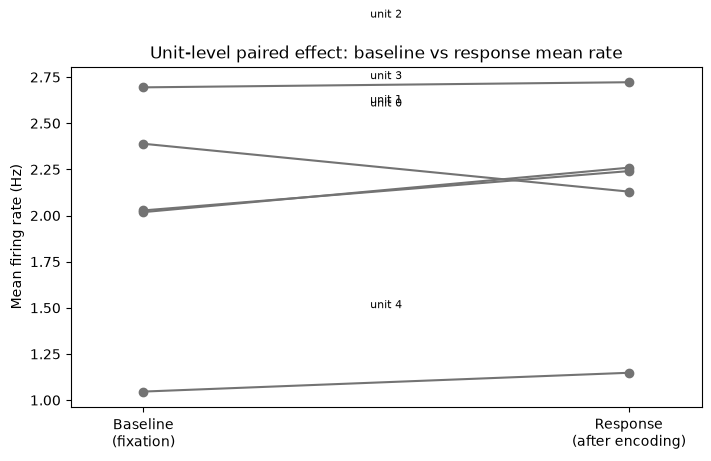

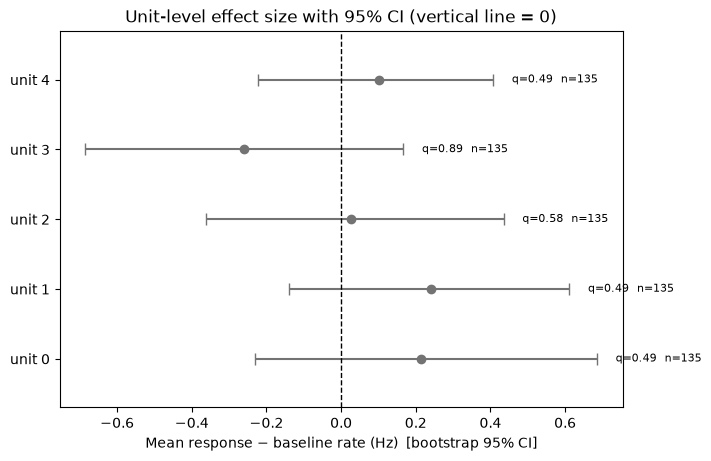

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 从 unit_trial_features 汇总每个 unit 的平均 baseline / response 放电率（Hz）。
means = unit_trial_features.groupby("unit_id")[
    ["baseline_rate_hz", "response_rate_hz"]
].mean()
sig_color = "tab:red"
null_color = "0.45"

# ---------- 图 A：unit 级配对效应（baseline → response 均值连线） ----------
fig_a, ax_a = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for i, unit_id in enumerate(means.index):
    is_sig = bool(result.loc[unit_id, "significant_q05"])
    color = sig_color if is_sig else null_color
    x = np.array([0.0, 1.0])
    y = [means.loc[unit_id, "baseline_rate_hz"], means.loc[unit_id, "response_rate_hz"]]
    ax_a.plot(x, y, marker="o", color=color, lw=1.5)
    ax_a.text(0.5, max(y) + 0.35, f"unit {unit_id}", ha="center", fontsize=8)
ax_a.set_xticks([0, 1], ["Baseline\n(fixation)", "Response\n(after encoding)"])
ax_a.set_ylabel("Mean firing rate (Hz)")
ax_a.set_xlim(-0.15, 1.15)
ax_a.set_title("Unit-level paired effect: baseline vs response mean rate")
plt.show()

# ---------- 图 B：效应量与不确定性（mean ± bootstrap 95% CI）森林图 ----------
order = result.index.to_list()
n = len(order)
fig_b, ax_b = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
for i, unit_id in enumerate(order):
    row = result.loc[unit_id]
    is_sig = bool(row["significant_q05"])
    color = sig_color if is_sig else null_color
    lo = row["ci95_lower_hz"]
    hi = row["ci95_upper_hz"]
    mean = row["mean_delta_hz"]
    ax_b.errorbar(mean, i, xerr=[[mean - lo], [hi - mean]],
                  fmt="o", color=color, capsize=4, markersize=6)
    # 在右侧标注 q 值与 trial 数，方便读图而不必回去翻表。
    ax_b.text(hi + 0.05, i, f"q={row['fdr_q']:.2f}  n={int(row['n_trials'])}",
              va="center", fontsize=8)
ax_b.axvline(0, color="black", ls="--", lw=1)
ax_b.set_yticks(range(n), [f"unit {u}" for u in order])
ax_b.set_xlabel("Mean response − baseline rate (Hz)  [bootstrap 95% CI]")
ax_b.set_ylim(-0.7, n - 0.3)
ax_b.set_title("Unit-level effect size with 95% CI (vertical line = 0)")
plt.show()

# 第六段（里程碑 6）主检验第 4 步：最终汇总图

## 从顶层设计看，这一段有什么用？

顶层设计 §17 计划生成五张图，其中里程碑 6 负责两张“结果性”图：**unit 级配对效应图**（图 3）与**效应量与不确定性汇总图**（图 4）。前几段已经跑完了置换检验、bootstrap CI 与 FDR，本步把它们画出来，方便肉眼判断结果是否由少数极端 unit 驱动，以及哪些 unit 的响应方向相对稳健。两张图直接在 notebook 内显示，不单独保存为 PNG 文件。

## 图 A：unit 级配对效应（如何阅读）

横轴是两个时间条件：左边 `Baseline (fixation)`、右边 `Response (after encoding)`；纵轴是平均放电率（Hz）。每个 unit 一条从 baseline 均值连到 response 均值的线段，两点都用圆圈标出。某条线**向右上倾斜**表示该 unit 图片后的平均放电率高于其 trial 内基线；**向下倾斜**则相反。线段颜色区分是否通过 FDR（本 session 中没有 unit 通过，因此当前全部为灰色）。

它的作用是把“统计结论”还原成“原始的平均放电变化”：即使某 unit 未达 FDR 显著，仍可看出它的平均响应相对基线是升还是降。要注意平均放电率只跨 135 个 trial 汇总，点之间没有误差棒，不确定范围由图 B 呈现。

## 图 B：效应量 + 95% CI（森林图，如何阅读）

横轴是 `mean response − baseline` 差值（Hz），竖直虚线是 0（无差异）。每个 unit 一个横向误差棒：圆点是 `mean_delta_hz`，横线是 bootstrap 95% CI 的跨度。误差棒完全在虚线 0 右侧才说明该 unit 在 95% 置信水平上图片后稳定高于基线；完全在左侧则稳定低于；**跨越 0** 表示方向存在、但证据不足以排除无差异。右侧直接标出该 unit 的 `q` 值与 trial 数，使读图者不用回头翻表。

## 本次输出与结论

- 图 A、图 B 直接显示在 notebook 内；出于仓库整洁考虑，不单独保存为 PNG 文件（结果图可从 notebook 导出）。
- 本 session 的诚实读图结论：多个 unit 的平均响应方向为正，但 95% CI 都跨 0、FDR 后均不显著，说明这 5 个 QC 合格 unit 在预先定义的窗口与规则下，**没有给出足够证据表明第一张编码图片后的放电率显著高于同一 trial 的 fixation 基线**。这个负结果只适用于这个 session，不推广到其他被试或全脑。